# Animals-10 Image Classification — Final Project

**Course:** ITAI 1378 Computer Vision and AI  
**Student:** Laura Conover  
**Tier:** Tier 1  
**Dataset:** Animals-10 from Kaggle  
**Model:** MobileNetV2 transfer learning

## What this notebook does

This notebook:

1. Downloads the real Animals-10 photograph dataset from Kaggle.
2. Detects and translates the original Italian folder labels.
3. Creates a balanced working dataset.
4. Splits the images into training, validation, and test sets.
5. Trains a MobileNetV2 image-classification model.
6. Measures performance on unseen test images.
7. Creates accuracy, loss, confusion-matrix, and sample-prediction outputs.
8. Lets you upload a new image for a live prediction.
9. Saves the model and final-project results.

> The full Animals-10 dataset is large. By default, this notebook uses up to 500 images per class, or about 5,000 real photographs. You can increase that number later.


## Before running

In Google Colab:

1. Open **Runtime → Change runtime type**.
2. Select **T4 GPU**.
3. Run each cell in order.

The notebook first tries Kaggle's current Python download library. If Kaggle requests authentication, follow the instructions printed by the download cell.


In [1]:
# Cell 1: Install and import the required libraries

!pip -q install kagglehub

import os
import json
import random
import shutil
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from google.colab import files
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

SEED = 1378
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Cell 2: Download Animals-10 from Kaggle

DATASET_HANDLE = "alessiocorrado99/animals10"

try:
    downloaded_path = pathlib.Path(
        kagglehub.dataset_download(DATASET_HANDLE)
    )
    print("Dataset downloaded to:", downloaded_path)
except Exception as error:
    print("Automatic download did not finish.")
    print("Error:", error)
    print()
    print("Kaggle may require authentication.")
    print("Open Kaggle → Settings → API → Create New Token.")
    print("Then upload kaggle.json in the next cell and rerun this cell.")
    raise


Using Colab cache for faster access to the 'animals10' dataset.
Dataset downloaded to: /kaggle/input/animals10


In [ ]:
# Optional authentication cell — run only if Kaggle asks for credentials

# 1. Download kaggle.json from your Kaggle account settings.
# 2. Uncomment the lines below.
# 3. Run this cell.
# 4. Rerun the download cell above.

# uploaded = files.upload()
# if "kaggle.json" not in uploaded:
#     raise ValueError("Please upload the file named kaggle.json.")
#
# kaggle_directory = pathlib.Path.home() / ".kaggle"
# kaggle_directory.mkdir(exist_ok=True)
#
# token_path = kaggle_directory / "kaggle.json"
# token_path.write_bytes(uploaded["kaggle.json"])
# os.chmod(token_path, 0o600)
#
# print("Kaggle credentials installed. Rerun Cell 2.")


In [3]:
# Cell 3: Locate the original image folders

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

ITALIAN_TO_ENGLISH = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel",
}

def count_images(folder):
    return sum(
        1
        for item in folder.iterdir()
        if item.is_file() and item.suffix.lower() in IMAGE_EXTENSIONS
    )

def locate_class_root(search_root):
    search_root = pathlib.Path(search_root)
    candidates = []

    folders_to_check = [search_root]
    folders_to_check.extend(
        folder for folder in search_root.rglob("*") if folder.is_dir()
    )

    for folder in folders_to_check:
        child_folders = [item for item in folder.iterdir() if item.is_dir()]
        matching_children = [
            child
            for child in child_folders
            if child.name.lower() in ITALIAN_TO_ENGLISH
            and count_images(child) > 0
        ]

        if len(matching_children) >= 8:
            candidates.append((folder, len(matching_children)))

    if not candidates:
        raise FileNotFoundError(
            "Could not locate the Animals-10 class folders."
        )

    candidates.sort(key=lambda item: item[1], reverse=True)
    return candidates[0][0]

original_class_root = locate_class_root(downloaded_path)

print("Original class root:", original_class_root)
print()
print("Detected categories:")

for folder in sorted(original_class_root.iterdir()):
    if folder.is_dir() and folder.name.lower() in ITALIAN_TO_ENGLISH:
        print(
            f"{folder.name:12s} → "
            f"{ITALIAN_TO_ENGLISH[folder.name.lower()]:10s} "
            f"({count_images(folder)} images)"
        )


Original class root: /kaggle/input/animals10/raw-img

Detected categories:
cane         → dog        (4863 images)
cavallo      → horse      (2623 images)
elefante     → elephant   (1446 images)
farfalla     → butterfly  (2112 images)
gallina      → chicken    (3098 images)
gatto        → cat        (1668 images)
mucca        → cow        (1866 images)
pecora       → sheep      (1820 images)
ragno        → spider     (4821 images)
scoiattolo   → squirrel   (1862 images)


In [4]:
# Cell 4: Build a balanced English-labeled working dataset

# Keep 500 for a manageable proof of concept.
# Increase this later to use more images per category.
MAX_IMAGES_PER_CLASS = 500

working_root = pathlib.Path("/content/animals10_balanced")

if working_root.exists():
    shutil.rmtree(working_root)

working_root.mkdir(parents=True)

class_counts = {}

for italian_name, english_name in ITALIAN_TO_ENGLISH.items():
    source_folder = original_class_root / italian_name
    destination_folder = working_root / english_name
    destination_folder.mkdir(parents=True)

    image_files = [
        file
        for file in source_folder.iterdir()
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    random.Random(SEED).shuffle(image_files)
    selected_files = image_files[:MAX_IMAGES_PER_CLASS]

    copied = 0

    for index, source_file in enumerate(selected_files):
        extension = source_file.suffix.lower()
        destination_file = (
            destination_folder /
            f"{english_name}_{index + 1:04d}{extension}"
        )

        try:
            shutil.copy2(source_file, destination_file)
            copied += 1
        except Exception as error:
            print("Skipped:", source_file.name, error)

    class_counts[english_name] = copied

print("Balanced dataset created at:", working_root)
print("Images copied by class:", class_counts)
print("Total working images:", sum(class_counts.values()))


Balanced dataset created at: /content/animals10_balanced
Images copied by class: {'dog': 500, 'horse': 500, 'elephant': 500, 'butterfly': 500, 'chicken': 500, 'cat': 500, 'cow': 500, 'sheep': 500, 'spider': 500, 'squirrel': 500}
Total working images: 5000


In [5]:
# Cell 5: Check and remove unreadable image files

from PIL import Image

removed_files = []

for image_path in working_root.rglob("*"):
    if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
        try:
            with Image.open(image_path) as image:
                image.verify()
        except Exception:
            removed_files.append(str(image_path))
            image_path.unlink()

print("Unreadable images removed:", len(removed_files))

clean_counts = {
    class_folder.name: count_images(class_folder)
    for class_folder in sorted(working_root.iterdir())
    if class_folder.is_dir()
}

print("Clean image counts:", clean_counts)
print("Total clean images:", sum(clean_counts.values()))


Unreadable images removed: 0
Clean image counts: {'butterfly': 500, 'cat': 500, 'chicken': 500, 'cow': 500, 'dog': 500, 'elephant': 500, 'horse': 500, 'sheep': 500, 'spider': 500, 'squirrel': 500}
Total clean images: 5000


In [16]:
# Cell 6: Create training, validation, and test datasets

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# First reserve 20% as a temporary validation/test pool.
train_dataset = tf.keras.utils.image_dataset_from_directory(
    working_root,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

temporary_dataset = tf.keras.utils.image_dataset_from_directory(
    working_root,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

class_names = train_dataset.class_names
number_of_classes = len(class_names)

# Divide the reserved 20% into approximately 10% validation and 10% test.
temporary_batches = tf.data.experimental.cardinality(
    temporary_dataset
).numpy()

validation_batches = max(1, temporary_batches // 2)

validation_dataset = temporary_dataset.take(validation_batches)
test_dataset = temporary_dataset.skip(validation_batches)

print("Class names:", class_names)
print("Number of classes:", number_of_classes)
print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())


Found 5000 files belonging to 10 classes.
Using 4000 files for training.
Found 5000 files belonging to 10 classes.
Using 1000 files for validation.
Class names: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Number of classes: 10
Training batches: 125
Validation batches: 16
Test batches: 16


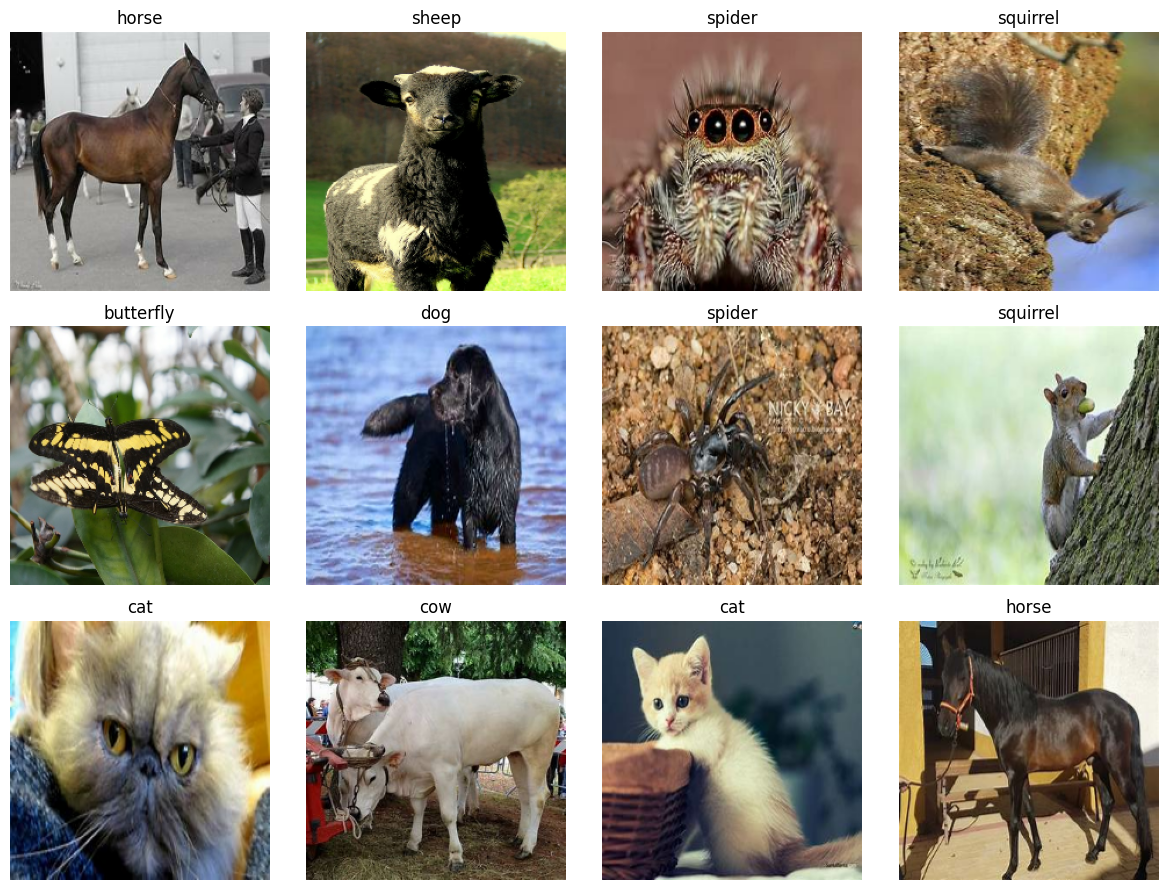

In [17]:
# Cell 7: Display real sample images

plt.figure(figsize=(12, 9))

for images, labels in train_dataset.take(1):
    for index in range(min(12, len(images))):
        plt.subplot(3, 4, index + 1)
        plt.imshow(images[index].numpy().astype("uint8"))
        plt.title(class_names[int(labels[index])])
        plt.axis("off")

plt.tight_layout()
plt.savefig("/content/sample_real_animals.png", bbox_inches="tight")
plt.show()


In [18]:
# Cell 8: Improve input performance

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

print("Datasets are ready.")


Datasets are ready.


In [19]:
# Cell 9: Build the MobileNetV2 transfer-learning model

data_augmentation = models.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation",
)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(
    number_of_classes,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
# Cell 10: Compile and train the model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_animals10_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
    ),
]

EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - accuracy: 0.7690 - loss: 0.7662 - val_accuracy: 0.9355 - val_loss: 0.2269 - learning_rate: 0.0010
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.9060 - loss: 0.3119 - val_accuracy: 0.9453 - val_loss: 0.1836 - learning_rate: 0.0010
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.9302 - loss: 0.2335 - val_accuracy: 0.9609 - val_loss: 0.1489 - learning_rate: 0.0010
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.9333 - loss: 0.2128 - val_accuracy: 0.9629 - val_loss: 0.1401 - learning_rate: 0.0010
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.9457 - loss: 0.1904 - val_accuracy: 0.9531 - val_loss: 0.1418 - learning_rate: 0.0010
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.9392 - loss: 0.1773 - val_accuracy: 0.9570 - val_loss: 0.1396 - learning_rate: 0.0010
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.9523 - loss: 

In [21]:
# Cell 11: Evaluate on the unseen test dataset

test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1,
)

print(f"Final test accuracy: {test_accuracy * 100:.2f}%")
print(f"Final test loss: {test_loss:.4f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9611 - loss: 0.1534
Final test accuracy: 96.11%
Final test loss: 0.1534


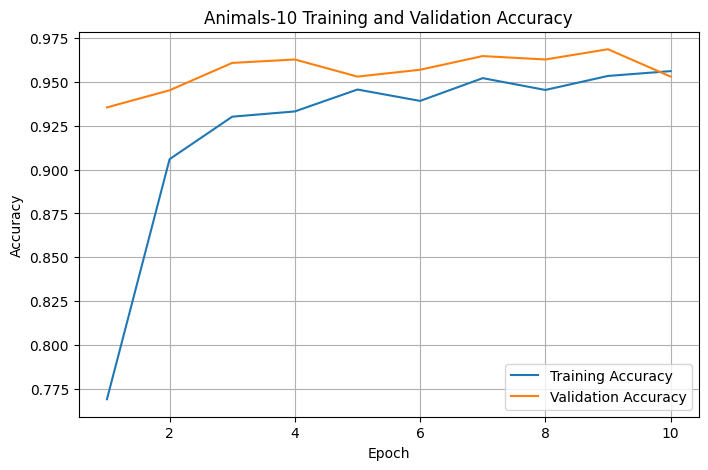

In [22]:
# Cell 12: Create the accuracy graph

epochs_completed = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(
    epochs_completed,
    history.history["accuracy"],
    label="Training Accuracy",
)
plt.plot(
    epochs_completed,
    history.history["val_accuracy"],
    label="Validation Accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Animals-10 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("/content/accuracy_graph.png", bbox_inches="tight")
plt.show()


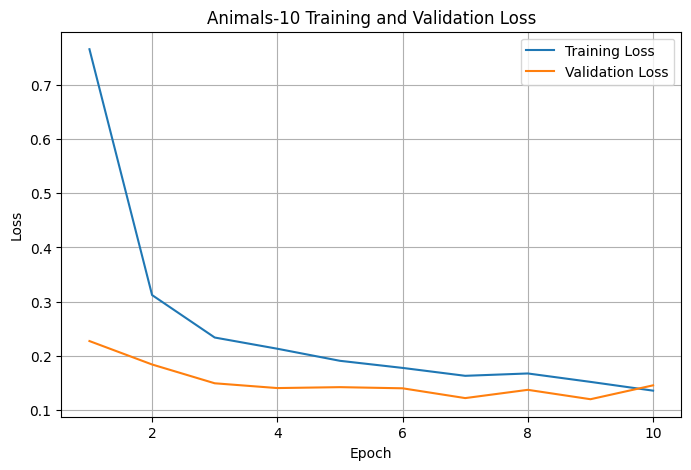

In [23]:
# Cell 13: Create the loss graph

plt.figure(figsize=(8, 5))
plt.plot(
    epochs_completed,
    history.history["loss"],
    label="Training Loss",
)
plt.plot(
    epochs_completed,
    history.history["val_loss"],
    label="Validation Loss",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Animals-10 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("/content/loss_graph.png", bbox_inches="tight")
plt.show()


In [24]:
# Cell 14: Create predictions and the classification report

true_labels = []
predicted_labels = []
prediction_confidences = []
test_images_for_examples = []

for images, labels in test_dataset:
    probabilities = model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)
    confidences = np.max(probabilities, axis=1)

    true_labels.extend(labels.numpy().tolist())
    predicted_labels.extend(predictions.tolist())
    prediction_confidences.extend(confidences.tolist())

    for image, true_label, predicted_label, confidence in zip(
        images.numpy(),
        labels.numpy(),
        predictions,
        confidences,
    ):
        test_images_for_examples.append(
            (
                image,
                int(true_label),
                int(predicted_label),
                float(confidence),
            )
        )

report = classification_report(
    true_labels,
    predicted_labels,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0,
)

print(report)


              precision    recall  f1-score   support

   butterfly       0.98      1.00      0.99        50
         cat       0.98      0.94      0.96        49
     chicken       0.98      0.98      0.98        53
         cow       0.97      0.93      0.95        40
         dog       0.91      0.96      0.93        50
    elephant       0.98      0.98      0.98        47
       horse       0.93      0.95      0.94        55
       sheep       0.90      0.96      0.92        45
      spider       1.00      0.97      0.99        36
    squirrel       1.00      0.95      0.98        63

    accuracy                           0.96       488
   macro avg       0.96      0.96      0.96       488
weighted avg       0.96      0.96      0.96       488



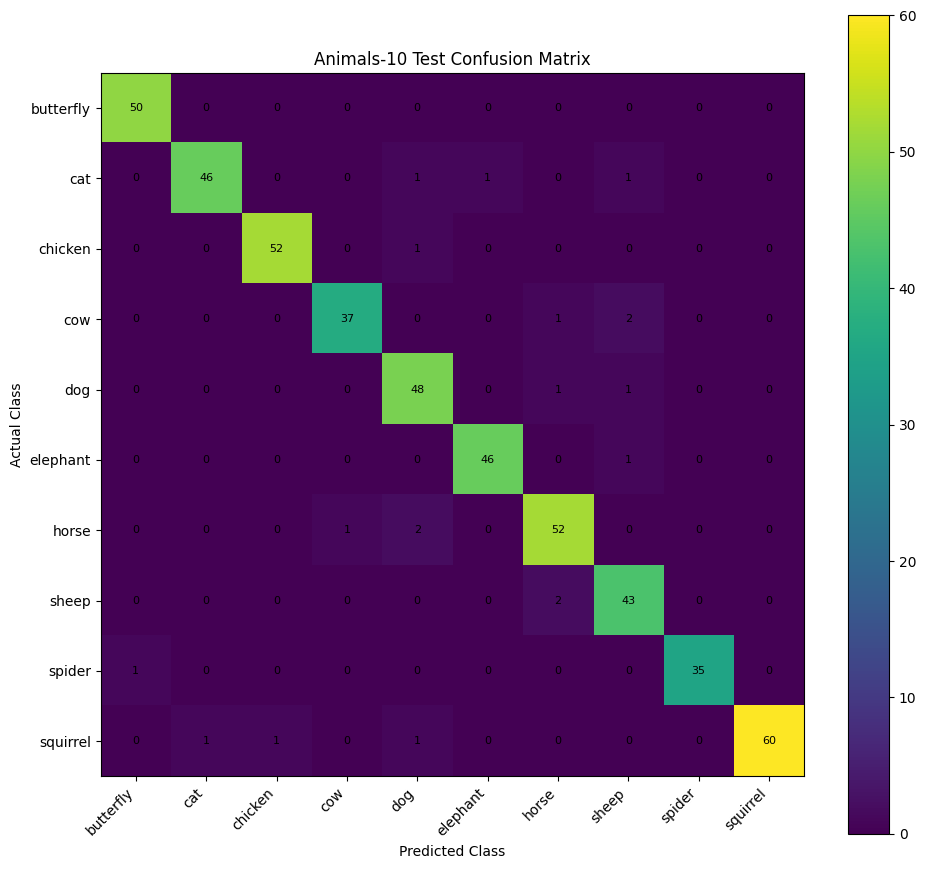

In [25]:
# Cell 15: Create the confusion matrix

matrix = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10, 9))
plt.imshow(matrix)
plt.title("Animals-10 Test Confusion Matrix")
plt.colorbar()

tick_positions = np.arange(number_of_classes)

plt.xticks(
    tick_positions,
    class_names,
    rotation=45,
    ha="right",
)
plt.yticks(tick_positions, class_names)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        plt.text(
            column,
            row,
            matrix[row, column],
            ha="center",
            va="center",
            fontsize=8,
        )

plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", bbox_inches="tight")
plt.show()


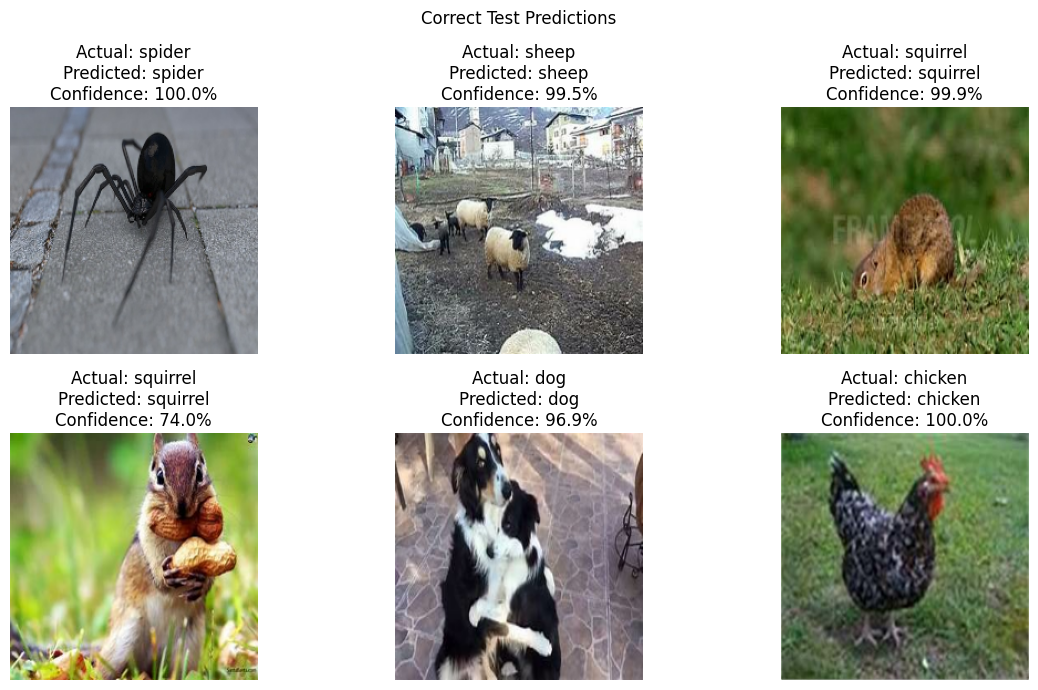

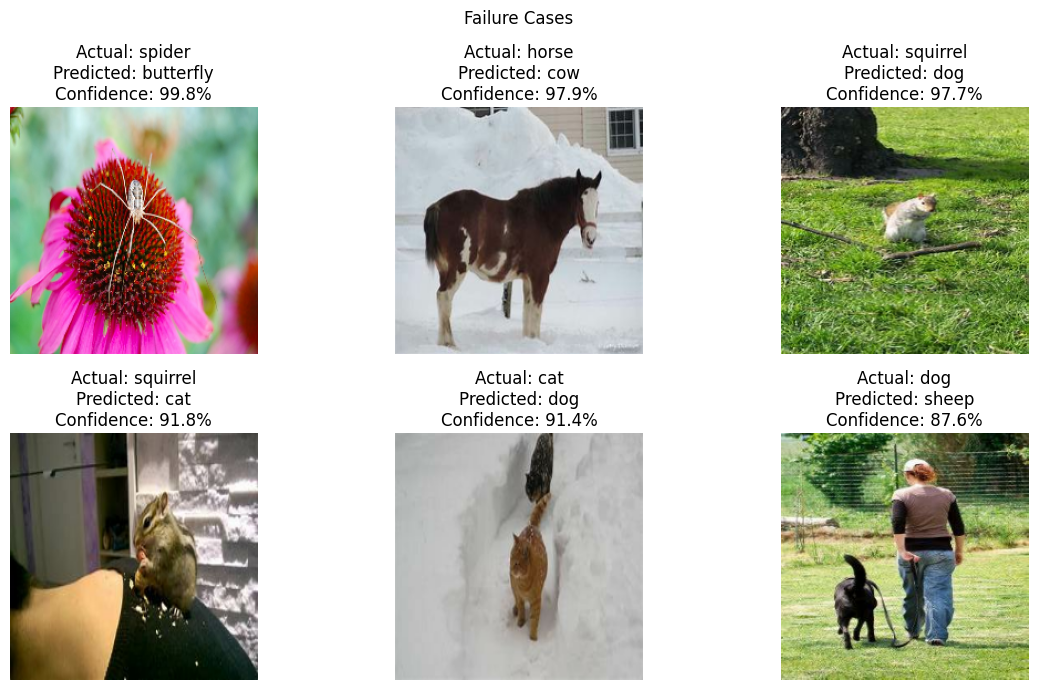

In [26]:
# Cell 16: Show correct and incorrect test predictions

correct_examples = [
    item for item in test_images_for_examples
    if item[1] == item[2]
]

incorrect_examples = [
    item for item in test_images_for_examples
    if item[1] != item[2]
]

# Sort incorrect cases by confidence so a clear failure case appears first.
incorrect_examples.sort(key=lambda item: item[3], reverse=True)

def display_prediction_examples(examples, title, filename, maximum=6):
    if not examples:
        print("No examples available for:", title)
        return

    examples = examples[:maximum]

    plt.figure(figsize=(12, 7))

    for index, (image, true_label, predicted_label, confidence) in enumerate(examples):
        plt.subplot(2, 3, index + 1)
        plt.imshow(image.astype("uint8"))
        plt.axis("off")
        plt.title(
            f"Actual: {class_names[true_label]}\n"
            f"Predicted: {class_names[predicted_label]}\n"
            f"Confidence: {confidence * 100:.1f}%"
        )

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

display_prediction_examples(
    correct_examples,
    "Correct Test Predictions",
    "/content/correct_predictions.png",
)

display_prediction_examples(
    incorrect_examples,
    "Failure Cases",
    "/content/failure_cases.png",
)


## Live demo

Run the next cell during your presentation or video. Upload a real animal photograph, and the model will show:

- Predicted animal class
- Confidence score
- Top three predictions

Try one clear image and one difficult image.


In [ ]:
# Cell 17: Upload a new real photograph for prediction

def predict_uploaded_image():
    print("Upload one animal photograph.")
    uploaded = files.upload()

    if not uploaded:
        raise ValueError("No image was uploaded.")

    image_path = next(iter(uploaded))

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMAGE_SIZE,
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_batch = tf.expand_dims(image_array, axis=0)

    probabilities = model.predict(image_batch, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    confidence = float(probabilities[predicted_index])

    top_indices = np.argsort(probabilities)[::-1][:3]

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Prediction: {class_names[predicted_index]}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    plt.savefig("/content/latest_uploaded_prediction.png", bbox_inches="tight")
    plt.show()

    print("Predicted animal:", class_names[predicted_index])
    print(f"Confidence: {confidence * 100:.2f}%")
    print()
    print("Top three predictions:")

    for index in top_indices:
        print(
            f"{class_names[int(index)]}: "
            f"{probabilities[int(index)] * 100:.2f}%"
        )

predict_uploaded_image()


In [29]:
# Cell 18: Save the trained model and final result summary

final_model_path = "/content/animals10_classifier.keras"
model.save(final_model_path)

results_summary = f'''
Animals-10 Image Classification Final Results

Dataset source:
Kaggle — alessiocorrado99/animals10

Working images:
{sum(clean_counts.values())}

Classes:
{class_names}

Images by class:
{clean_counts}

Model:
MobileNetV2 transfer learning

Test accuracy:
{test_accuracy * 100:.2f}%

Test loss:
{test_loss:.4f}

Classification Report:
{report}
'''

with open("/content/model_results.txt", "w") as result_file:
    result_file.write(results_summary)

with open("/content/class_names.json", "w") as class_file:
    json.dump(class_names, class_file, indent=2)

print(results_summary)
print("Saved:", final_model_path)



Animals-10 Image Classification Final Results

Dataset source:
Kaggle — alessiocorrado99/animals10

Working images:
5000

Classes:
['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']

Images by class:
{'butterfly': 500, 'cat': 500, 'chicken': 500, 'cow': 500, 'dog': 500, 'elephant': 500, 'horse': 500, 'sheep': 500, 'spider': 500, 'squirrel': 500}

Model:
MobileNetV2 transfer learning

Test accuracy:
96.11%

Test loss:
0.1534

Classification Report:
              precision    recall  f1-score   support

   butterfly       0.98      1.00      0.99        50
         cat       0.98      0.94      0.96        49
     chicken       0.98      0.98      0.98        53
         cow       0.97      0.93      0.95        40
         dog       0.91      0.96      0.93        50
    elephant       0.98      0.98      0.98        47
       horse       0.93      0.95      0.94        55
       sheep       0.90      0.96      0.92        45
      spider 

In [30]:
# Cell 19: Package the presentation results into one ZIP file

result_files = [
    "/content/sample_real_animals.png",
    "/content/accuracy_graph.png",
    "/content/loss_graph.png",
    "/content/confusion_matrix.png",
    "/content/correct_predictions.png",
    "/content/failure_cases.png",
    "/content/latest_uploaded_prediction.png",
    "/content/model_results.txt",
    "/content/class_names.json",
]

results_folder = pathlib.Path("/content/animals10_final_results")

if results_folder.exists():
    shutil.rmtree(results_folder)

results_folder.mkdir()

for file_path in result_files:
    source = pathlib.Path(file_path)
    if source.exists():
        shutil.copy2(source, results_folder / source.name)

archive_path = shutil.make_archive(
    "/content/animals10_final_results",
    "zip",
    results_folder,
)

print("Results ZIP created:", archive_path)
files.download(archive_path)


Results ZIP created: /content/animals10_final_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>